# Question 1 - NN Basics

## I. Fitting Data

Simulate the following DGP: y = sin(x)+ε. You can consider x∈[0,2π]

In [41]:
using Random 
using Distributions
Random.seed!(123)
n = 1000 
X = Float32.(2π .* rand(n, 1)) 
eps = Float32.(rand(Normal(0, 0.15), n, 1)) 
y = Float32.(sin.(X) .+ eps)
X_train = permutedims(X) 
y_train = permutedims(y)
modelos = Dict{String, Any}()

Dict{String, Any}()

Next, train a NN to predict y with 3 hidden layers, each with 50 neurons. Try the following activation functions:
- logistic
- tanh
- relu

In [42]:
import Pkg
Pkg.add("Flux")

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


In [43]:
using Flux

# -------------------------------
# Red con activación LOGISTIC (sigmoide)
# -------------------------------
mlp_logistic = Chain(
    Dense(1, 50, σ),
    Dense(50, 50, σ),
    Dense(50, 50, σ),
    Dense(50, 1)
)

loss(model, x, y) = Flux.Losses.mse(model(x), y)
opt_logistic = Flux.Optimisers.Adam(0.01)
state_logistic = Flux.setup(opt_logistic, mlp_logistic)

for i in 1:5000
    grads = gradient(m -> loss(m, X_train, y_train), mlp_logistic)
    Flux.Optimisers.update!(state_logistic, mlp_logistic, grads[1])
end

modelos["logistic"] = mlp_logistic

# -------------------------------
# Red con activación TANH
# -------------------------------
mlp_tanh = Chain(
    Dense(1, 50, tanh),
    Dense(50, 50, tanh),
    Dense(50, 50, tanh),
    Dense(50, 1)
)

opt_tanh = Flux.Optimisers.Adam(0.01)
state_tanh = Flux.setup(opt_tanh, mlp_tanh)

for i in 1:5000
    grads = gradient(m -> loss(m, X_train, y_train), mlp_tanh)
    Flux.Optimisers.update!(state_tanh, mlp_tanh, grads[1])
end

modelos["tanh"] = mlp_tanh

# -------------------------------
# Red con activación ReLU
# -------------------------------
mlp_relu = Chain(
    Dense(1, 50, relu),
    Dense(50, 50, relu),
    Dense(50, 50, relu),
    Dense(50, 1)
)

# Definimos optimizador y su estado
opt_relu = Flux.Optimisers.Adam(0.01)
state_relu = Flux.setup(opt_relu, mlp_relu)

# Entrenamiento (igual estructura que los anteriores)
for i in 1:5000
    grads = gradient(m -> loss(m, X_train, y_train), mlp_relu)
    Flux.Optimisers.update!(state_relu, mlp_relu, grads[1])
end

# Guardamos el modelo
modelos["relu"] = mlp_relu

println("✅ Modelos entrenados correctamente y guardados en el diccionario.")

✅ Modelos entrenados correctamente y guardados en el diccionario.


Finally, train another NN with the same characteristics but using a different activation function for each hidden layer (you can leave any other parameters as default when training the NN).

In [44]:
# -------------------------------
# Red neuronal con activaciones mixtas
# -------------------------------
mixed_nn = Chain(
    Dense(1, 50, tanh),    # 1ª capa -> tanh
    Dense(50, 50, relu),   # 2ª capa -> ReLU
    Dense(50, 50, σ),      # 3ª capa -> sigmoid
    Dense(50, 1)           # capa de salida (lineal)
)

# -------------------------------
# Pérdida y optimizador
# -------------------------------
loss(model, x, y) = Flux.Losses.mse(model(x), y)
opt = Flux.Optimisers.Adam(0.01)
state = Flux.setup(opt, mixed_nn)

# -------------------------------
# Entrenamiento
# -------------------------------
for epoch in 1:4000
    grads = gradient(m -> loss(m, X_train, y_train), mixed_nn)
    Flux.Optimisers.update!(state, mixed_nn, grads[1])

    if epoch % 1000 == 0
        current_loss = loss(mixed_nn, X_train, y_train)
        println("Epoch $epoch, Loss = $(round(current_loss, digits=4))")
    end
end

model_mixto = mixed_nn
modelos["mixto"] = model_mixto

println("✅ Modelo mixto entrenado correctamente.")

Epoch 1000, Loss = 0.0228
Epoch 2000, Loss = 0.0236
Epoch 3000, Loss = 0.0228
Epoch 4000, Loss = 0.0228
✅ Modelo mixto entrenado correctamente.


For each NN trained, plot the data and the fitted values in the XY-plane Which NN fits the data better?

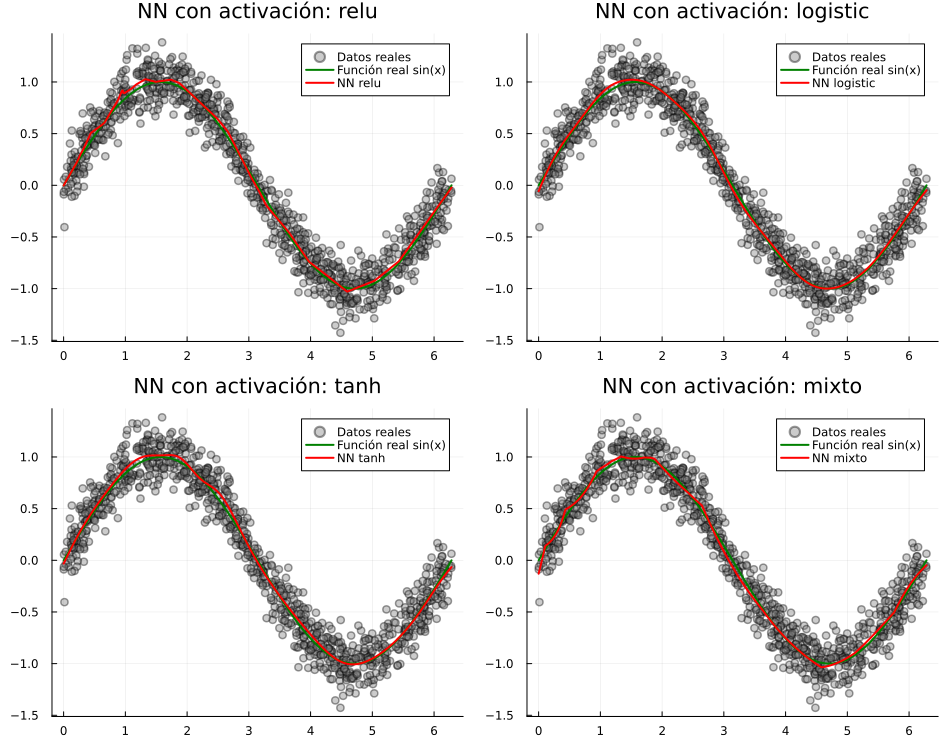

✅ Gráficos generados correctamente.


In [45]:
using Plots
x_grid = reshape(Float32.(collect(LinRange(0, 2π, 500))), :, 1)
y_true = sin.(x_grid)

predicciones = Dict{String, Any}()

for (nombre, modelo) in modelos
    y_pred = modelo(permutedims(x_grid)) |> Array |> vec
    predicciones[nombre] = y_pred
end

# Layout 2x2 (4 modelos)
plt = plot(layout = (2, 2), size = (950, 750))

for (i, (nombre, y_pred)) in enumerate(predicciones)
    scatter!(
        plt[i], X[:], y[:],
        color = :gray, alpha = 0.4,
        label = "Datos reales", legend = :topright
    )
    plot!(
        plt[i], x_grid[:], y_true[:],
        color = :green, lw = 2,
        label = "Función real sin(x)"
    )
    plot!(
        plt[i], x_grid[:], y_pred[:],
        color = :red, lw = 2,
        label = "NN $nombre"
    )
    title!(plt[i], "NN con activación: $nombre")
end

display(plt)
println("✅ Gráficos generados correctamente.")

In [46]:
mse_resultados = Dict{String, Float64}()

for (nombre, y_pred) in predicciones
    mse = mean((Float64.(sin.(x_grid[:])) .- Float64.(y_pred)).^2)
    mse_resultados[nombre] = mse
    println(rpad(nombre, 10), " -> MSE: ", round(mse, digits=6))
end

# Encontrar el modelo con menor MSE
mejor_mse, mejor_nombre = findmin(mse_resultados)

println()
println("✅ Mejor modelo según MSE: ", mejor_nombre)
println("   MSE = ", round(mejor_mse, digits=6))

relu       -> MSE: 0.000993
logistic   -> MSE: 0.000487
tanh       -> MSE: 0.000739
mixto      -> MSE: 0.000908

✅ Mejor modelo según MSE: logistic
   MSE = 0.000487


## II. Learning-rate

Briefly explain what the learning-rate is in the context of Neural Networks.

- The learning rate in a neural network is basically the speed at which the model learns.

- During training, the network adjusts its internal parameters (weights) to reduce prediction errors — kind of like how an economist updates expectations when new data comes in. The learning rate determines how big those adjustments are each time the model learns from the data.

- If the learning rate is too high, the model makes big jumps and might miss the best solution.

- If it’s too low, it moves very slowly and can get stuck before reaching the optimal point.

Use the same data simulation and the activation function that performed better between logistic, tanh, and relu. Iterate over the following learning rates training for each iteration a NN of a single hidden layer with 50 neurons. 0.0001, 0.001, 0.01, 0.1

In [47]:
using Flux, Random, Distributions, Statistics

# ===============================================================
# Diccionario para mapear nombres → funciones de activación
# ===============================================================
activaciones = Dict(
    "logistic" => σ,
    "tanh"     => tanh,
    "relu"     => relu,
    "mixto"    => tanh   # si mixto gana, usa tanh por defecto
)

# ===============================================================
# Learning rates a probar
# ===============================================================
learning_rates = [0.0001, 0.001, 0.01, 0.1]
modelos_lr = Dict{Float64, Any}()
predicciones_lr = Dict{Float64, Any}()
mse_lr = Dict{Float64, Float64}()

# ===============================================================
# Elegir función de activación ganadora
# ===============================================================
act_fn = activaciones[mejor_nombre]   # ← ahora es una función real

println("➤ Usando activación ganadora: $mejor_nombre")

# ===============================================================
# Entrenar una NN con la mejor activación detectada
# ===============================================================
for lr in learning_rates
    println("Entrenando NN con learning rate = $lr")

    # Crear red neuronal correctamente
    model = Chain(
        Dense(1, 50, act_fn),
        Dense(50, 1)
    )

    # Definir pérdida y optimizador
    loss(m, x, y) = Flux.Losses.mse(m(x), y)
    opt = Flux.Optimisers.Adam(lr)
    state = Flux.setup(opt, model)

    # Entrenamiento
    for epoch in 1:5000
        grads = gradient(m -> loss(m, X_train, y_train), model)
        Flux.Optimisers.update!(state, model, grads[1])
    end

    # Predicciones
    y_pred = model(permutedims(x_grid)) |> Array |> vec
    predicciones_lr[lr] = y_pred

    # MSE
    mse = mean((Float64.(y_true[:]) .- Float64.(y_pred)).^2)
    mse_lr[lr] = mse

    println("  → MSE = ", round(mse, digits=6))
end


➤ Usando activación ganadora: logistic
Entrenando NN con learning rate = 0.0001
  → MSE = 0.194421
Entrenando NN con learning rate = 0.001
  → MSE = 0.0007
Entrenando NN con learning rate = 0.01
  → MSE = 0.000637
Entrenando NN con learning rate = 0.1
  → MSE = 0.000281


In one single graph, plot the data and the fitted values in the XY-plane. Properly label the graph and answer which learning rate worked best.

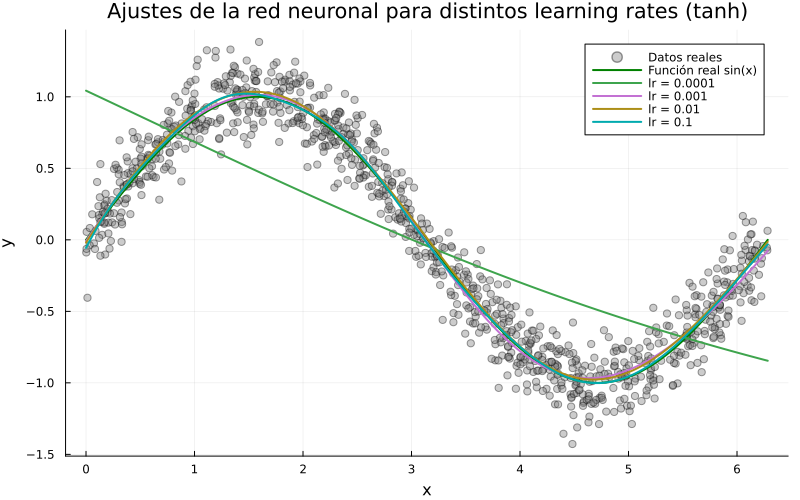

Learning rate 0.0001: MSE = 0.194421
Learning rate 0.01: MSE = 0.000637
Learning rate 0.1: MSE = 0.000281
Learning rate 0.001: MSE = 0.0007

✅ Mejor learning rate: 0.1 (menor MSE = 0.000281)


In [48]:
using Plots, Statistics

# ===============================================================
# 1. GRAFICAR TODAS LAS CURVAS POR LEARNING RATE
# ===============================================================
plt = plot(size = (800, 500))

# Datos originales y función real
scatter!(plt, X[:], y[:], color = :gray, alpha = 0.4, label = "Datos reales")
plot!(plt, x_grid[:], y_true[:], color = :green, lw = 2, label = "Función real sin(x)")

# Curvas predichas por cada learning rate
for (lr, y_pred) in sort(collect(predicciones_lr))  # ordena por valor de lr
    plot!(plt, x_grid[:], y_pred[:], lw = 2, label = "lr = $lr")
end

xlabel!("x")
ylabel!("y")
title!("Ajustes de la red neuronal para distintos learning rates (tanh)")
plot!(legend = :topright)
display(plt)

# ===============================================================
# 2. CALCULAR MSE PARA CADA LEARNING RATE
# ===============================================================
mse_lr = Dict{Float64, Float64}()

for (lr, y_pred) in predicciones_lr
    mse = mean((Float64.(y_true[:]) .- Float64.(y_pred)).^2)
    mse_lr[lr] = mse
    println("Learning rate ", lr, ": MSE = ", round(mse, digits = 6))
end

# Encontrar el mejor learning rate
mejor_mse, mejor_lr = findmin(mse_lr)

println("\n✅ Mejor learning rate: ", mejor_lr,
        " (menor MSE = ", round(mejor_mse, digits = 6), ")")

Repeat this process (training and graph) for a NN with 2 hidden layers, and 3 hidden layers (each layer with 50 neurons).


==================== 2 hidden layers ====================
Entrenando NN con learning rate = 0.0001
  → MSE = 0.00028
Entrenando NN con learning rate = 0.001
  → MSE = 0.000217
Entrenando NN con learning rate = 0.01
  → MSE = 0.000475
Entrenando NN con learning rate = 0.1
  → MSE = 0.49927


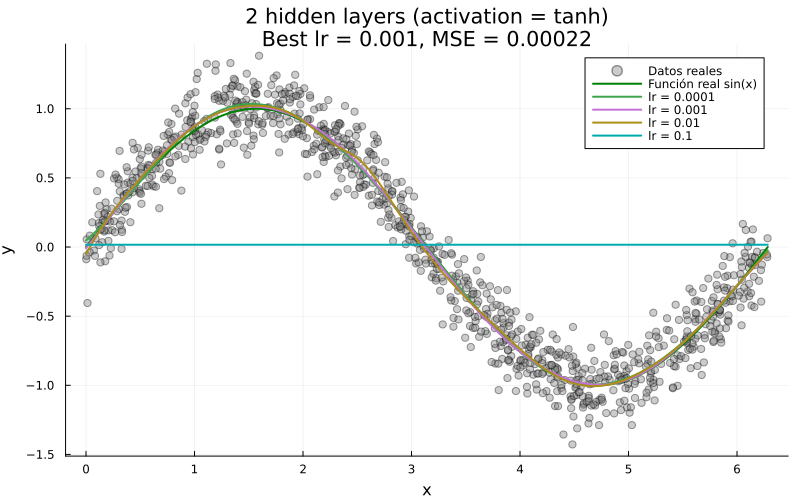

MSE por learning rate:
  lr = 0.0001: MSE = 0.00028
  lr = 0.01: MSE = 0.000475
  lr = 0.1: MSE = 0.49927
  lr = 0.001: MSE = 0.000217
✅ Mejor learning rate para 2 hidden layers: 0.001 (MSE = 0.000217)

==================== 1 hidden layer ====================
Entrenando NN con learning rate = 0.0001
  → MSE = 0.104893
Entrenando NN con learning rate = 0.001
  → MSE = 0.000247
Entrenando NN con learning rate = 0.01
  → MSE = 0.000288
Entrenando NN con learning rate = 0.1
  → MSE = 0.004273


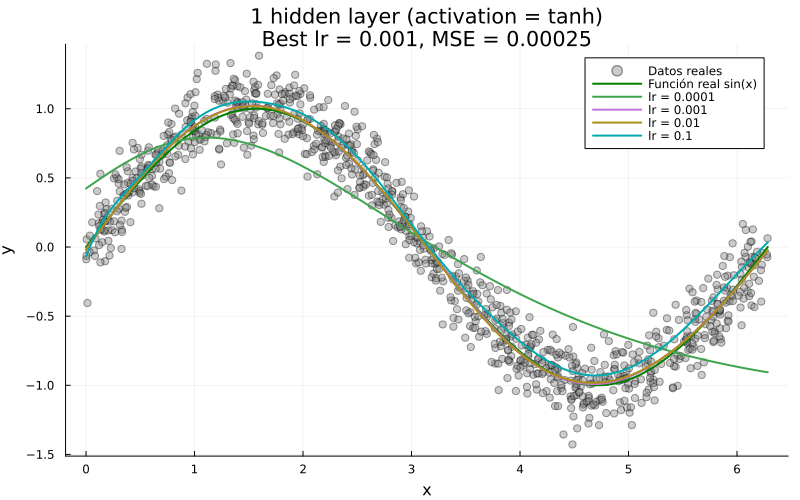

MSE por learning rate:
  lr = 0.0001: MSE = 0.104893
  lr = 0.01: MSE = 0.000288
  lr = 0.1: MSE = 0.004273
  lr = 0.001: MSE = 0.000247
✅ Mejor learning rate para 1 hidden layer: 0.001 (MSE = 0.000247)

==================== 3 hidden layers ====================
Entrenando NN con learning rate = 0.0001
  → MSE = 0.000202
Entrenando NN con learning rate = 0.001
  → MSE = 0.000253
Entrenando NN con learning rate = 0.01
  → MSE = 0.00065
Entrenando NN con learning rate = 0.1
  → MSE = 0.066223


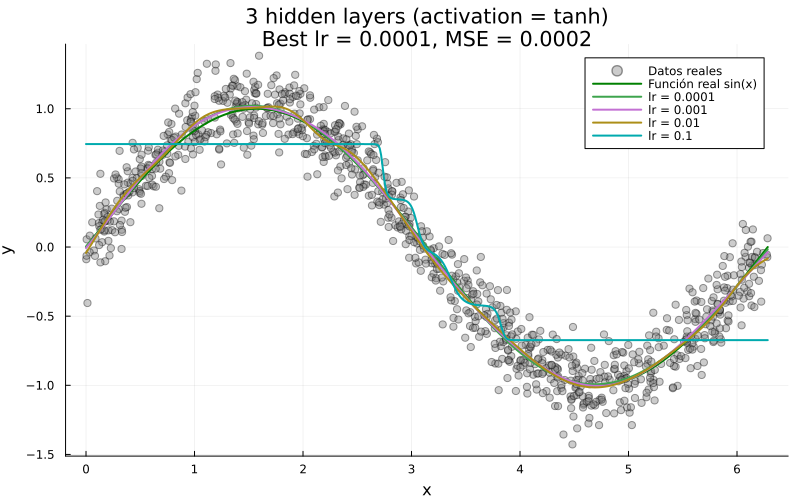

MSE por learning rate:
  lr = 0.0001: MSE = 0.000202
  lr = 0.01: MSE = 0.00065
  lr = 0.1: MSE = 0.066223
  lr = 0.001: MSE = 0.000253
✅ Mejor learning rate para 3 hidden layers: 0.0001 (MSE = 0.000202)

✅ Comparación completa de arquitecturas terminada.


In [49]:
using Flux, Random, Distributions, Statistics, Plots

# ===============================================================
# LEARNING RATES Y ARQUITECTURAS A PROBAR
# ===============================================================
learning_rates = [0.0001, 0.001, 0.01, 0.1]

architectures = Dict(
    "1 hidden layer" => (50,),
    "2 hidden layers" => (50, 50),
    "3 hidden layers" => (50, 50, 50)
)

# ===============================================================
# ITERAR SOBRE CADA ARQUITECTURA
# ===============================================================
for (arch_name, arch) in architectures
    println("\n==================== $arch_name ====================")

    predicciones_lr = Dict{Float64, Any}()
    mse_lr = Dict{Float64, Float64}()

    # Entrenar un modelo por cada learning rate
    for lr in learning_rates
        println("Entrenando NN con learning rate = $lr")

        # Construir la red dinámicamente según arquitectura
        layers = []
        in_dim = 1
        for h in arch
            push!(layers, Dense(in_dim, h, tanh))
            in_dim = h
        end
        push!(layers, Dense(in_dim, 1))  # capa de salida
        model = Chain(layers...)

        # Definir pérdida y optimizador
        loss(m, x, y) = Flux.Losses.mse(m(x), y)
        opt = Flux.Optimisers.Adam(lr)
        state = Flux.setup(opt, model)

        # Entrenamiento
        for epoch in 1:5000
            grads = gradient(m -> loss(m, X_train, y_train), model)
            Flux.Optimisers.update!(state, model, grads[1])
        end

        # Predicciones y error
        y_pred = model(permutedims(x_grid)) |> Array |> vec
        mse = mean((Float64.(y_true[:]) .- Float64.(y_pred)).^2)
        predicciones_lr[lr] = y_pred
        mse_lr[lr] = mse
        println("  → MSE = ", round(mse, digits=6))
    end

    # ===========================================================
    # GRAFICAR TODAS LAS CURVAS PARA ESTA ARQUITECTURA
    # ===========================================================
    plt = plot(size = (800, 500))
    scatter!(plt, X[:], y[:], color = :gray, alpha = 0.4, label = "Datos reales")
    plot!(plt, x_grid[:], y_true[:], color = :green, lw = 2, label = "Función real sin(x)")

    for (lr, y_pred) in sort(collect(predicciones_lr))
        plot!(plt, x_grid[:], y_pred[:], lw = 2, label = "lr = $lr")
    end

    # Hallar mejor learning rate
    mejor_mse, mejor_lr = findmin(mse_lr)

    title!(plt, "$arch_name (activation = tanh)\nBest lr = $mejor_lr, MSE = $(round(mejor_mse, digits=5))")
    xlabel!("x")
    ylabel!("y")
    plot!(legend = :topright)
    display(plt)

    # ===========================================================
    # IMPRIMIR RESUMEN
    # ===========================================================
    println("MSE por learning rate:")
    for (lr, mse) in mse_lr
        println("  lr = $(lr): MSE = ", round(mse, digits=6))
    end
    println("✅ Mejor learning rate para $arch_name: $(mejor_lr) (MSE = $(round(mejor_mse, digits=6)))")
end

println("\n✅ Comparación completa de arquitecturas terminada.")


In this illustrative example, what can you say about the relationship between the learning rate and the number of hidden layers?

In this illustrative example, the optimal learning rate tends to decrease slightly as the network becomes deeper.
For 1 and 2 hidden layers, the best-performing learning rate is 0.001, while for 3 hidden layers the best learning rate falls to 0.0001.
Moreover, high learning rates such as 0.1 become increasingly unstable as depth increases, leading to much larger errors in deeper networks.
This is consistent with the idea that deeper networks are more sensitive to the choice of learning rate and generally benefit from smaller, more conservative step sizes.